## **1. Import Library**

In [ ]:
import os
import re
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print("Semua library berhasil diimport!")
print(f"PyTorch version : {torch.__version__}")

Semua library berhasil diimport!
PyTorch version : 2.10.0+cpu


## **2. Set Device**

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device yang digunakan: {device.upper()}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print('GPU tersedia')
else:
    print('Berjalan di CPU')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
print(f'Random seed  : {SEED}')

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total

Device yang digunakan: CPU
Berjalan di CPU
Random seed  : 42


## **3. Load Dataset Text**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive berhasil di-mount!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive berhasil di-mount!


In [ ]:
DATASET_PATH = (
    "/content/drive/MyDrive/[S2] Semester 2/Pembelajaran Mesin/"
    "[Generative AI] Tugas Implementasi /"
    "[Text] Implementasi Generative AI /Dataset/puisi.csv"
)

df = pd.read_csv(DATASET_PATH)
print(f"Shape       : {df.shape}")
print(f"Kolom       : {df.columns.tolist()}")
print(f"Jumlah puisi: {len(df):,}")

df['panjang'] = df['puisi'].str.len()
print(f"\nStatistik Panjang Puisi (karakter):")
print(f"Min    : {df['panjang'].min()}")
print(f"Max    : {df['panjang'].max()}")
print(f"Rata²  : {df['panjang'].mean():.0f}")
print(f"Median : {df['panjang'].median():.0f}")
print(f"Total  : {df['panjang'].sum():,} karakter")

print(f"\nContoh Puisi #1:")
print("=" * 56)
print(df['puisi'].iloc[0][:300])
print("=" * 56)
print(f"\nContoh Puisi #2:")
print("=" * 56)
print(df['puisi'].iloc[1][:300])
print("=" * 56)

Shape       : (7223, 1)
Kolom       : ['puisi']
Jumlah puisi: 7,223

Statistik Panjang Puisi (karakter):
Min    : 147.0
Max    : 8734.0
Rata²  : 691
Median : 585
Total  : 4,987,943.0 karakter

Contoh Puisi #1:
Tiada lagi resah di hatiku 
 Tiada lagi keraguan kini 
 Aku yakin hanyalah dirimu 
 Yang ku sayangi 
 Setiap langkah akupunBerjanji..................... 
 Akan selalau setia bersama 
 Kaulah nafasku 
 Kaulah khayalanku 
 Kaulah damai dalam detak jantungkuOh.............. 
 kasih 
 Peluklah diriku 
 

Contoh Puisi #2:
Gemericik senandung luluh merayu hati, 
 Terjamah larutan mensiasati. 
  
 Terus menyabani hingga rengkarnasi. 
 Putih sejuk teramat berarti. 
 Senantiasa menanti keputusan Tuhan kapan ia akan pergi. 
  
 Bila sampai waktu nya, 
 Tetes demi tetes kian mengurai  awan. 
 Gemuruh kilat pelepas ikatan. 


## **4. Preprocessing Text**

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Normalisasi whitespace
    text = re.sub(r'[ \t]+', ' ', text)
    # Normalisasi newline
    text = re.sub(r'\n+', '\n', text)
    # Hapus karakter selain huruf, angka, spasi, tanda baca dasar, newline
    text = re.sub(r"[^a-zA-Z0-9 .,!?\n'-]", '', text)
    text = text.strip()
    return text


# Terapkan cleaning
df['puisi_clean'] = df['puisi'].apply(clean_text)

# Hapus puisi yang terlalu pendek (< 50 karakter)
df = df[df['puisi_clean'].str.len() >= 50].reset_index(drop=True)

print(f"Jumlah puisi setelah cleaning: {len(df):,}")

Jumlah puisi setelah cleaning: 7,221


In [ ]:
CORPUS_SIZE = 500_000

# Gabung semua puisi, pisahkan dengan separator <eop>
full_corpus = '\n<eop>\n'.join(df['puisi_clean'].tolist())

# Ambil subset
if CORPUS_SIZE and len(full_corpus) > CORPUS_SIZE:
    corpus = full_corpus[:CORPUS_SIZE]
    print(f'Corpus dipotong: {CORPUS_SIZE:,} karakter (dari {len(full_corpus):,})')
else:
    corpus = full_corpus
    print(f'Menggunakan seluruh corpus: {len(corpus):,} karakter')

print(f'\nInfo Corpus:')
print(f'Panjang corpus  : {len(corpus):,} karakter')

# ─── Bangun Vocabulary (Character-level) ────────────────────
# Kumpulkan semua karakter unik dalam corpus
chars      = sorted(set(corpus))
VOCAB_SIZE = len(chars)

# Mapping dua arah: karakter ↔ indeks integer
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for ch, i in char2idx.items()}

print(f'Vocab size      : {VOCAB_SIZE} karakter unik')

# ─── Encode corpus ke array integer ─────────────────────────
encoded = np.array([char2idx[ch] for ch in corpus], dtype=np.int64)
print(f'\nEncoded shape: {encoded.shape}')

sample_tokens = ''.join([idx2char[i] for i in encoded[:5]])

print(f'5 token pertama : {encoded[:5]} → {sample_tokens!r}')

Corpus dipotong: 500,000 karakter (dari 4,974,499)

Info Corpus:
Panjang corpus  : 500,000 karakter
Vocab size      : 46 karakter unik

Encoded shape: (500000,)
5 token pertama : [39 28 20 23 20] → 'tiada'


In [ ]:
# ─── Hyperparameter ──────────────────
SEQ_LEN       = 80     # panjang sequence input; lebih pendek = lebih cepat
BATCH_SIZE    = 64     # batch kecil = hemat RAM & CPU
EMBED_DIM     = 64     # dimensi embedding
HIDDEN_DIM    = 128    # hidden state LSTM
NUM_LAYERS    = 1      # 1 layer = jauh lebih cepat di CPU vs 2 layer
NUM_HEADS     = 4      # head attention Transformer
FF_DIM        = 256    # feedforward dim Transformer
TF_LAYERS     = 1      # 1 layer Transformer untuk kecepatan
DROPOUT       = 0.2
NUM_EPOCHS    = 5     # cukup untuk melihat konvergensi
LEARNING_RATE = 0.002


class PuisiDataset(Dataset):
    def __init__(self, encoded_data, seq_len):
        self.data    = encoded_data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx          : idx + self.seq_len]      # input
        y = self.data[idx + 1      : idx + self.seq_len + 1]  # target
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)


# ─── Split Train / Val (90 / 10) ────────────────────────────
split     = int(len(encoded) * 0.9)
train_enc = encoded[:split]
val_enc   = encoded[split:]

train_ds  = PuisiDataset(train_enc, SEQ_LEN)
val_ds    = PuisiDataset(val_enc,   SEQ_LEN)

# num_workers=0 paling stabil di Colab CPU
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  drop_last=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, drop_last=True, num_workers=0)

print(f'Train sequences : {len(train_ds):,}')
print(f'Val   sequences : {len(val_ds):,}')
print(f'Train batches   : {len(train_loader):,}')
print(f'Val   batches   : {len(val_loader):,}')
print(f'\nHyperparameter:')
print(f'SEQ_LEN       = {SEQ_LEN}')
print(f'BATCH_SIZE    = {BATCH_SIZE}')
print(f'EMBED_DIM     = {EMBED_DIM}')
print(f'HIDDEN_DIM    = {HIDDEN_DIM}  (LSTM)')
print(f'NUM_LAYERS    = {NUM_LAYERS}')
print(f'NUM_EPOCHS    = {NUM_EPOCHS}')
print(f'LEARNING_RATE = {LEARNING_RATE}')

# Cek sample
sx, sy = train_ds[0]
input_text = ''.join([idx2char[i.item()] for i in sx[:100]])
target_text = ''.join([idx2char[i.item()] for i in sy[:100]])

print(f'\nSample shape : x={sx.shape}, y={sy.shape}')

print(f'Input  : {input_text!r}')
print(f'Target : {target_text!r}')

Train sequences : 449,920
Val   sequences : 49,920
Train batches   : 7,030
Val   batches   : 780

Hyperparameter:
SEQ_LEN       = 80
BATCH_SIZE    = 64
EMBED_DIM     = 64
HIDDEN_DIM    = 128  (LSTM)
NUM_LAYERS    = 1
NUM_EPOCHS    = 5
LEARNING_RATE = 0.002

Sample shape : x=torch.Size([80]), y=torch.Size([80])
Input  : 'tiada lagi resah di hatiku \n tiada lagi keraguan kini \n aku yakin hanyalah dirim'
Target : 'iada lagi resah di hatiku \n tiada lagi keraguan kini \n aku yakin hanyalah dirimu'


## **5. Definisi Model Generatif Text**

In [ ]:
class LSTMGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super(LSTMGenerator, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding: indeks karakter → dense vector (B, T) → (B, T, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # LSTM: memproses urutan secara sekuensial
        # batch_first=True → input shape (batch, seq, features)
        self.lstm = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True
        )

        self.dropout = nn.Dropout(dropout)

        # Projection: hidden state → logits per karakter di vocab
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        # x      : (B, T)   — indeks karakter
        # return : logits (B, T, vocab_size), hidden baru
        embed       = self.dropout(self.embedding(x))   # (B, T, embed_dim)
        out, hidden = self.lstm(embed, hidden)           # (B, T, hidden_dim)
        out         = self.dropout(out)
        logits      = self.fc(out)                       # (B, T, vocab_size)
        return logits, hidden

    def init_hidden(self, batch_size):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        return (h, c)


# Inisialisasi
lstm_model = LSTMGenerator(
    vocab_size = VOCAB_SIZE,
    embed_dim  = EMBED_DIM,
    hidden_dim = HIDDEN_DIM,
    num_layers = NUM_LAYERS,
    dropout    = DROPOUT
).to(device)

print(f'Total parameter : {count_parameters(lstm_model):,}')
print(f'\nArsitektur LSTM:')
print(lstm_model)

Total parameter : 108,206

Arsitektur LSTM:
LSTMGenerator(
  (embedding): Embedding(46, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=46, bias=True)
)


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, dropout=0.1, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe       = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2).float() * -(math.log(10000.0) / embed_dim)
        )
        pe[:, 0::2] = torch.sin(position * div_term)   # dimensi genap
        pe[:, 1::2] = torch.cos(position * div_term)   # dimensi ganjil
        self.register_buffer('pe', pe.unsqueeze(0))    # (1, max_len, embed_dim)

    def forward(self, x):
        # x: (B, T, embed_dim)
        return self.dropout(x + self.pe[:, :x.size(1), :])


class TransformerGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim,
                 num_layers, dropout, max_seq=600):
        super(TransformerGenerator, self).__init__()
        self.embed_dim = embed_dim

        self.embedding    = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim, dropout, max_seq)

        # Satu TransformerDecoderLayer untuk kecepatan di CPU
        decoder_layer = nn.TransformerDecoderLayer(
            d_model         = embed_dim,
            nhead           = num_heads,
            dim_feedforward = ff_dim,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True     # Pre-LN: lebih stabil
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(embed_dim, vocab_size)

        # Inisialisasi bobot — Xavier untuk stabilitas
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _causal_mask(self, seq_len, dev):
        return torch.triu(
            torch.ones(seq_len, seq_len, device=dev), diagonal=1
        ).bool()

    def forward(self, x):
        # x: (B, T)
        T    = x.size(1)
        mask = self._causal_mask(T, x.device)

        # Embedding + scaling + PE
        emb  = self.embedding(x) * math.sqrt(self.embed_dim)  # (B, T, embed_dim)
        emb  = self.pos_encoding(emb)

        # Decoder-only: memory = emb (tidak ada encoder terpisah)
        out    = self.transformer(tgt=emb, memory=emb,
                                  tgt_mask=mask, memory_mask=mask)
        logits = self.fc_out(out)   # (B, T, vocab_size)
        return logits


# Inisialisasi
tf_model = TransformerGenerator(
    vocab_size = VOCAB_SIZE,
    embed_dim  = EMBED_DIM,
    num_heads  = NUM_HEADS,
    ff_dim     = FF_DIM,
    num_layers = TF_LAYERS,
    dropout    = DROPOUT
).to(device)

print(f'Total parameter : {count_parameters(tf_model):,}')
print(f'\nArsitektur Transformer:')
print(tf_model)

Total parameter : 72,686

Arsitektur Transformer:
TransformerGenerator(
  (embedding): Embedding(46, 64)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer): TransformerDecoder(
    (layers): ModuleList(
      (0): TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
     

## **6. Penjelasan Rumus Model Text**

### Penjelasan Rumus Model LSTM

#### Rumus Text Generation
$$p(x_1, x_2, ..., x_T) = \prod_{t=1}^{T} p(x_t \mid x_1, ..., x_{t-1})$$

| Simbol | Keterangan | Kode PyTorch |
|--------|------------|--------------|
| `xₜ` | Token (karakter) pada posisi ke-t | `x[:, t]` |
| `Embedding` | Indeks → dense vector | `self.embedding(x)` |
| `hₜ, cₜ` | Hidden state & cell state LSTM | `lstm_out, hidden = self.lstm(embed)` |
| `logits` | Skor mentah per karakter | `self.fc(lstm_out)` |
| `p(xₜ\|...)` | Probabilitas karakter berikutnya | `F.softmax(logits, dim=-1)` |
| `L` | Cross Entropy Loss | `nn.CrossEntropyLoss()` |

#### Cross Entropy Loss
$$L = -\sum_{i=1}^{N} y_i \log(\hat{y}_i)$$

- `yᵢ` = karakter target sebenarnya (one-hot)  
- `ŷᵢ` = probabilitas karakter hasil prediksi  
- Semakin kecil loss → model semakin baik memprediksi karakter berikutnya

### Penjelasan Rumus Model Transformer

#### Self-Attention
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

| Simbol | Keterangan | Kode PyTorch |
|--------|------------|--------------|
| `Q` | Query matrix | `nn.MultiheadAttention` (internal) |
| `K` | Key matrix | `nn.MultiheadAttention` (internal) |
| `V` | Value matrix | `nn.MultiheadAttention` (internal) |
| `dₖ` | Dimensi key | `embed_dim // num_heads` |
| `softmax(...)` | Bobot perhatian | `F.softmax(...)` |
| `PE` | Positional Encoding | `self.pos_encoding(embed)` |
| Causal mask | Tidak boleh lihat masa depan | `generate_causal_mask(...)` |
| `logits` | Skor per token | `self.fc_out(out)` |

## **7. Training Model Text**

In [ ]:
# Loss: Cross Entropy = -Σ yᵢ log(ŷᵢ)
criterion = nn.CrossEntropyLoss()


def run_epoch(model, loader, optimizer, is_train, is_lstm, desc=''):
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    context    = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)   # (B, T)
            y_batch = y_batch.to(device)   # (B, T)

            if is_train:
                optimizer.zero_grad()

            # Forward pass
            if is_lstm:
                logits, _ = model(x_batch)       # (B, T, vocab_size)
            else:
                logits    = model(x_batch)       # (B, T, vocab_size)

            # Reshape untuk CrossEntropyLoss: (B*T, vocab) vs (B*T,)
            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                y_batch.reshape(-1)
            )

            if is_train:
                loss.backward()
                # Gradient clipping: cegah exploding gradient
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(loader)


print('Fungsi training siap!')

Fungsi training siap!


In [ ]:
lstm_opt  = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)
lstm_sch  = optim.lr_scheduler.CosineAnnealingLR(
    lstm_opt, T_max=NUM_EPOCHS, eta_min=1e-4
)

lstm_train_losses = []
lstm_val_losses   = []

print('Memulai Training LSTM...')
print('=' * 68)
print(f'  {"Epoch":<7} {"Train Loss":>12} {"Val Loss":>10} {"PPL":>8} {"Waktu":>8}')
print('-' * 68)

total_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tr_loss = run_epoch(lstm_model, train_loader, lstm_opt,
                        is_train=True,  is_lstm=True)
    va_loss = run_epoch(lstm_model, val_loader,   lstm_opt,
                        is_train=False, is_lstm=True)

    lstm_train_losses.append(tr_loss)
    lstm_val_losses.append(va_loss)
    lstm_sch.step()

    ppl     = math.exp(va_loss)
    elapsed = time.time() - t0
    print(f'  [{epoch:>2}/{NUM_EPOCHS}]  {tr_loss:>12.4f}  {va_loss:>10.4f}  {ppl:>8.1f}  {elapsed:>6.1f}s')

total_time = time.time() - total_start
print('=' * 68)
print(f'Training LSTM selesai!')
print(f'Total waktu      : {total_time:.1f}s ({total_time/60:.1f} menit)')
print(f'Final Train Loss : {lstm_train_losses[-1]:.4f}')
print(f'Final Val Loss   : {lstm_val_losses[-1]:.4f}')
print(f'Final Perplexity : {math.exp(lstm_val_losses[-1]):.2f}')

Memulai Training LSTM...
  Epoch     Train Loss   Val Loss      PPL    Waktu
--------------------------------------------------------------------
  [ 1/5]        1.4493      1.3279       3.8  1285.4s
  [ 2/5]        1.3264      1.3122       3.7  1275.5s
  [ 3/5]        1.3033      1.3067       3.7  1277.0s
  [ 4/5]        1.2903      1.3047       3.7  1342.5s
  [ 5/5]        1.2832      1.3011       3.7  1282.7s
Training LSTM selesai!
Total waktu      : 6463.1s (107.7 menit)
Final Train Loss : 1.2832
Final Val Loss   : 1.3011
Final Perplexity : 3.67


In [ ]:
tf_opt = optim.Adam(
    tf_model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9
)
tf_sch = optim.lr_scheduler.CosineAnnealingLR(
    tf_opt, T_max=NUM_EPOCHS, eta_min=1e-4
)

tf_train_losses = []
tf_val_losses   = []

print('Memulai Training Transformer...')
print('=' * 68)
print(f'  {"Epoch":<7} {"Train Loss":>12} {"Val Loss":>10} {"PPL":>8} {"Waktu":>8}')
print('-' * 68)

total_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tr_loss = run_epoch(tf_model, train_loader, tf_opt,
                        is_train=True,  is_lstm=False)
    va_loss = run_epoch(tf_model, val_loader,   tf_opt,
                        is_train=False, is_lstm=False)

    tf_train_losses.append(tr_loss)
    tf_val_losses.append(va_loss)
    tf_sch.step()

    ppl     = math.exp(va_loss)
    elapsed = time.time() - t0
    print(f'  [{epoch:>2}/{NUM_EPOCHS}]  {tr_loss:>12.4f}  {va_loss:>10.4f}  {ppl:>8.1f}  {elapsed:>6.1f}s')

total_time = time.time() - total_start
print('=' * 68)
print(f'Training Transformer selesai!')
print(f'Total waktu      : {total_time:.1f}s ({total_time/60:.1f} menit)')
print(f'Final Train Loss : {tf_train_losses[-1]:.4f}')
print(f'Final Val Loss   : {tf_val_losses[-1]:.4f}')
print(f'Final Perplexity : {math.exp(tf_val_losses[-1]):.2f}')

Memulai Training Transformer...
  Epoch     Train Loss   Val Loss      PPL    Waktu
--------------------------------------------------------------------
  [ 1/5]        1.8242      1.5809       4.9  2068.9s
  [ 2/5]        1.7393      1.5557       4.7  2068.0s
  [ 3/5]        1.7217      1.5487       4.7  2065.2s
  [ 4/5]        1.7099      1.5401       4.7  2072.4s
  [ 5/5]        1.7025      1.5338       4.6  2070.4s
Training Transformer selesai!
Total waktu      : 10344.8s (172.4 menit)
Final Train Loss : 1.7025
Final Val Loss   : 1.5338
Final Perplexity : 4.64


## **8. Generate Text dari Prompt**

In [ ]:
def generate_lstm(model, prompt, char2idx, idx2char,
                  max_len=300, temperature=0.8, top_k=10, device='cpu'):
    model.eval()
    # Karakter tidak dikenal → spasi
    ids       = [char2idx.get(c, char2idx.get(' ', 0)) for c in prompt.lower()]
    generated = list(prompt.lower())

    with torch.no_grad():
        # Bangun hidden state dari prompt
        x_prompt = torch.tensor([ids], dtype=torch.long).to(device)
        _, hidden = model(x_prompt)

        cur = ids[-1]   # karakter terakhir prompt
        for _ in range(max_len):
            x_in = torch.tensor([[cur]], dtype=torch.long).to(device)
            logits, hidden = model(x_in, hidden)   # (1, 1, vocab_size)
            logits = logits[0, 0] / temperature    # temperature scaling

            # Top-k filtering
            if top_k > 0:
                kval, _ = torch.topk(logits, top_k)
                logits[logits < kval[-1]] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            cur   = torch.multinomial(probs, 1).item()   # sample
            generated.append(idx2char[cur])

    return ''.join(generated)


def generate_transformer(model, prompt, char2idx, idx2char,
                         max_len=300, temperature=0.8, top_k=10, device='cpu'):
    model.eval()
    ids = [char2idx.get(c, char2idx.get(' ', 0)) for c in prompt.lower()]

    with torch.no_grad():
        for _ in range(max_len):
            ctx     = ids[-SEQ_LEN:]   # ambil max SEQ_LEN token terakhir
            x_in    = torch.tensor([ctx], dtype=torch.long).to(device)
            logits  = model(x_in)[0, -1, :] / temperature   # prediksi posisi terakhir

            if top_k > 0:
                kval, _ = torch.topk(logits, top_k)
                logits[logits < kval[-1]] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            nxt   = torch.multinomial(probs, 1).item()
            ids.append(nxt)

    return ''.join([idx2char[i] for i in ids])


print('Fungsi generate siap!')

Fungsi generate siap!


In [ ]:
# Pasangan (prompt, temperature)
test_cases = [
    ('aku cinta',         0.6),   # temperature rendah → lebih tertata
    ('hujan turun',       0.8),
    ('dalam kesunyian',   1.0),   # temperature sedang
    ('angin berhembus',   1.2),   # temperature tinggi → lebih kreatif/acak
]

print('=' * 68)
print('  HASIL GENERASI TEKS — LSTM')
print('=' * 68)

lstm_outputs = {}   # simpan untuk analisis
for prompt, temp in test_cases:
    out = generate_lstm(
        lstm_model, prompt, char2idx, idx2char,
        max_len=200, temperature=temp, top_k=10, device=device
    )
    lstm_outputs[(prompt, temp)] = out
    print(f'\nPrompt: "{prompt}"  |  temperature={temp}')
    print(f'{out}')
    print('-' * 50)

print('\n')
print('=' * 68)
print('HASIL GENERASI TEKS — TRANSFORMER')
print('=' * 68)

tf_outputs = {}
for prompt, temp in test_cases:
    out = generate_transformer(
        tf_model, prompt, char2idx, idx2char,
        max_len=200, temperature=temp, top_k=10, device=device
    )
    tf_outputs[(prompt, temp)] = out
    print(f'\nPrompt: "{prompt}"  |  temperature={temp}')
    print(f'{out}')
    print('-' * 50)

  HASIL GENERASI TEKS — LSTM

Prompt: "aku cinta"  |  temperature=0.6
aku cintan 
 aku terlalu bersama dalam mata 
 bersama dengan putra hidupku 
 
 ku tak bisa bersama kepada tanganku 
 dan mengalir dari pikiranku 
 kau adalah berharap mengudar ku 
 bukan semua bersama 
 mengap
--------------------------------------------------

Prompt: "hujan turun"  |  temperature=0.8
hujan turunya sinar 
 
 dan pertama kau meninggalkan dunia 
 
 desir 
 ku mengharapkan karena aku di sana 
 keras tak beralas dunia 
 di pulang 
 tuhan, menerima dan itu menanti 
 karena mungkin ku lekas 
 mungk
--------------------------------------------------

Prompt: "dalam kesunyian"  |  temperature=1.0
dalam kesunyianya 
 kita akan dibasar suci 
 
 terbakar penuh musak ada pada hanya satu pelimbang 
 batnya 
 mungkin pada soruan 
 memiliki senyumku 
 mengambang sebuah kata yang menutup kota ini 
 aku bagaiak menju
--------------------------------------------------

Prompt: "angin berhembus"  |  temperature=1.2
an

In [ ]:
print('=' * 68)
print('CONTOH OUTPUT YANG BAIK  (temperature=0.5, top_k=10)')
print('=' * 68)

prompt_good = 'aku rindu'
good_lstm = generate_lstm(
    lstm_model, prompt_good, char2idx, idx2char,
    max_len=250, temperature=0.5, top_k=10, device=device
)
good_tf = generate_transformer(
    tf_model, prompt_good, char2idx, idx2char,
    max_len=250, temperature=0.5, top_k=10, device=device
)

print(f'\n[LSTM]\n{good_lstm}')
print(f'\n[Transformer]\n{good_tf}')

print('\n')
print('=' * 68)
print('CONTOH OUTPUT KURANG BAIK  (temperature=1.5, top_k=0)')
print('=' * 68)
print('(temperature tinggi + tanpa top-k → lebih acak, tidak koheren)')

bad_lstm = generate_lstm(
    lstm_model, prompt_good, char2idx, idx2char,
    max_len=200, temperature=1.5, top_k=0, device=device
)
bad_tf = generate_transformer(
    tf_model, prompt_good, char2idx, idx2char,
    max_len=200, temperature=1.5, top_k=0, device=device
)

print(f'\n[LSTM]\n{bad_lstm}')
print(f'\n[Transformer]\n{bad_tf}')

CONTOH OUTPUT YANG BAIK  (temperature=0.5, top_k=10)

[LSTM]
aku rindukan 
 kini dengan tangan kalian 
 karena kau berikan ku 
 tak ada dan bersama semua berharap 
 aku tak berdebar di punya kenangan ku 
 kau selalu bersama 
 mengapa kau tersenyum 
 semua kelam akan ku malik aku salah di perasaan yang bahagia 
 dan per

[Transformer]
aku rinduk bersama mengharapan dan bersama semua 
 aku terbahagian pernah aku bersama 
 
 menghan aku tak terberlum mengharap membuat kau pernah kau membuatku 
 menjadi kau kau membuat kau menjadi kemalam dibawa 
 ketika aku sebuah dengan semua 
 kau menjadi 


CONTOH OUTPUT KURANG BAIK  (temperature=1.5, top_k=0)
(temperature tinggi + tanpa top-k → lebih acak, tidak koheren)

[LSTM]
aku rinduku, 
 berjuta mawarwya tak sedangkan critfa lail-mal hingga sugaan 
 tabinlah,. 
 terisi? dengan langkahlmaka sesaor inikau, 
 waktu sakit pahsi pijakan 
 1905887 
 2157 
 . . ... 
 untukkunyaasahalam

[Transformer]
aku rindu lai kutuc juja musana..,, ini
<eop>
apalle

In [ ]:
prompt_variants = [
    ('aku',                                   '① Sangat pendek (1 kata)'),
    ('aku rindu',                             '② Pendek (2 kata)'),
    ('aku rindu kamu setiap malam',           '③ Sedang (5 kata)'),
    ('aku rindu kamu setiap malam\nkala hujan turun perlahan', '④ Panjang (multi-baris)'),
]

print('=' * 68)
print('  EKSPERIMEN: PENGARUH PANJANG PROMPT  (temperature=0.8)')
print('=' * 68)

for model_label, gen_fn, model in [
    ('LSTM',        generate_lstm,        lstm_model),
    ('Transformer', generate_transformer, tf_model),
]:
    print(f'\n── {model_label} ──')
    for p_text, p_desc in prompt_variants:
        out = gen_fn(
            model, p_text, char2idx, idx2char,
            max_len=120, temperature=0.8, top_k=10, device=device
        )
        preview = out[:180].replace('\n', ' ↵ ')
        print(f'\n  {p_desc}')
        print(f'  Prompt : {repr(p_text)}')
        print(f'  Output : {preview}...')

  EKSPERIMEN: PENGARUH PANJANG PROMPT  (temperature=0.8)

── LSTM ──

  ① Sangat pendek (1 kata)
  Prompt : 'aku'
  Output : aku  ↵  kini tak membalas pengolang disinariku  ↵  mengapa seperti kemilihan  ↵  apa yang di terimakasih akan menjadi pemindar  ↵  ...

  ② Pendek (2 kata)
  Prompt : 'aku rindu'
  Output : aku rindukan  ↵   ↵  ketika ku kan menusuk kembali  ↵  bertahan  ↵  ku terilah menemani di kala diri ini  ↵  alingkan menggerakkan sang kub...

  ③ Sedang (5 kata)
  Prompt : 'aku rindu kamu setiap malam'
  Output : aku rindu kamu setiap malamu  ↵  mengenal membahan  ↵  sepulau bersekenang kerujanganmu  ↵  tuhan  ↵  ketika ku bertanya  ↵  tak dapat mengiringi kebahagiaan...

  ④ Panjang (multi-baris)
  Prompt : 'aku rindu kamu setiap malam\nkala hujan turun perlahan'
  Output : aku rindu kamu setiap malam ↵ kala hujan turun perlahanya pun bagaikan tidak akan kemarau mereka menghangatmu  ↵  sudah mengalir kembali menguring padamu  ↵  kaulah pahabas yang b...

── Transformer ──


## **9. Visualisasi Loss**

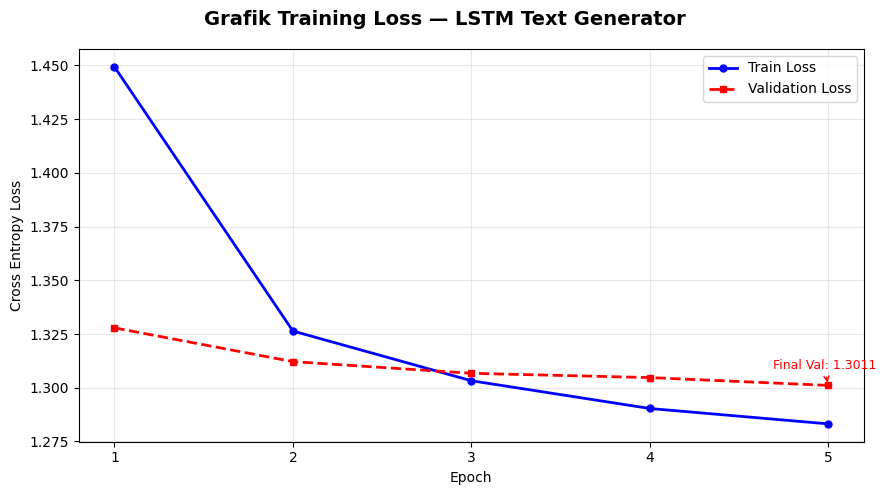

In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Grafik Training Loss — LSTM Text Generator',
             fontsize=14, fontweight='bold')

ax.plot(epochs_range, lstm_train_losses, 'b-o', markersize=5,
        label='Train Loss', linewidth=2)
ax.plot(epochs_range, lstm_val_losses,   'r--s', markersize=5,
        label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(list(epochs_range))
ax.annotate(
    f'Final Val: {lstm_val_losses[-1]:.4f}',
    xy=(NUM_EPOCHS, lstm_val_losses[-1]),
    xytext=(-40, 12), textcoords='offset points',
    fontsize=9, color='red',
    arrowprops=dict(arrowstyle='->', color='red')
)

plt.tight_layout()
plt.savefig('lstm_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

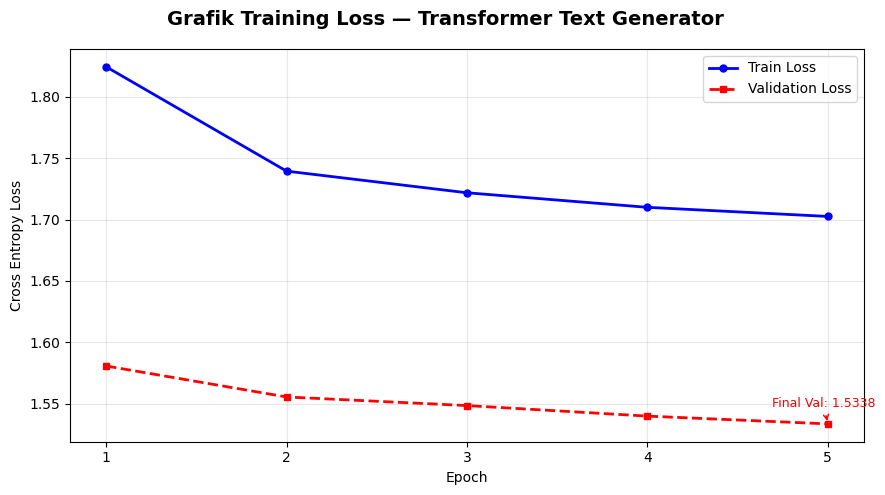

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Grafik Training Loss — Transformer Text Generator',
             fontsize=14, fontweight='bold')

ax.plot(epochs_range, tf_train_losses, 'b-o', markersize=5,
        label='Train Loss', linewidth=2)
ax.plot(epochs_range, tf_val_losses,   'r--s', markersize=5,
        label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(list(epochs_range))
ax.annotate(
    f'Final Val: {tf_val_losses[-1]:.4f}',
    xy=(NUM_EPOCHS, tf_val_losses[-1]),
    xytext=(-40, 12), textcoords='offset points',
    fontsize=9, color='red',
    arrowprops=dict(arrowstyle='->', color='red')
)

plt.tight_layout()
plt.savefig('transformer_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

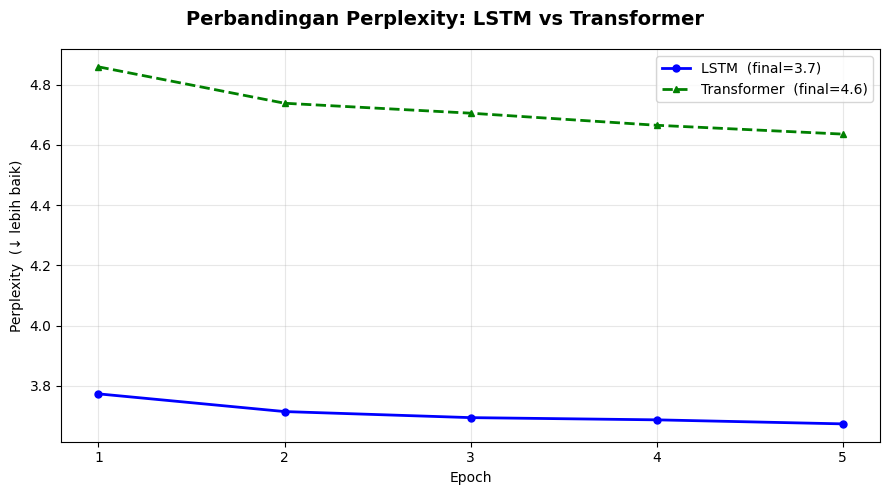

In [ ]:
lstm_ppls = [math.exp(l) for l in lstm_val_losses]
tf_ppls   = [math.exp(l) for l in tf_val_losses]

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Perbandingan Perplexity: LSTM vs Transformer',
             fontsize=14, fontweight='bold')

ax.plot(epochs_range, lstm_ppls, 'b-o', markersize=5, linewidth=2,
        label=f'LSTM  (final={lstm_ppls[-1]:.1f})')
ax.plot(epochs_range, tf_ppls,   'g--^', markersize=5, linewidth=2,
        label=f'Transformer  (final={tf_ppls[-1]:.1f})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Perplexity  (↓ lebih baik)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(list(epochs_range))

plt.tight_layout()
plt.savefig('perplexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## **10. Perbandingan Hasil**

In [ ]:
comp = {
    'Aspek': [
        'Tipe Model',
        'Cara Memproses Urutan',
        'Konteks',
        'Rumus Utama',
        'Loss Function',
        'Positional Info',
        'Paralelisasi Training',
        'Kemudahan Implementasi',
        'Jumlah Parameter',
        'Final Train Loss',
        'Final Val Loss',
        'Final Perplexity (Val)',
        'Repetisi Output',
        'Koherensi',
        'Kecepatan CPU',
    ],
    'LSTM': [
        'Recurrent (RNN)',
        'Sekuensial, token per token',
        'Dibatasi hidden state (vanishing gradient)',
        'Gate: fₜ, iₜ, oₜ, cₜ',
        'Cross Entropy',
        'Implisit (hidden state)',
        'Terbatas (sequential)',
        'Lebih sederhana',
        f'{count_parameters(lstm_model):,}',
        f'{lstm_train_losses[-1]:.4f}',
        f'{lstm_val_losses[-1]:.4f}',
        f'{math.exp(lstm_val_losses[-1]):.2f}',
        'Lebih sering',
        'Baik untuk urutan pendek',
        'Lebih cepat',
    ],
    'Transformer': [
        'Self-Attention (Decoder)',
        'Paralel, semua posisi sekaligus',
        'Seluruh context window',
        'Attention(Q,K,V)=softmax(QKᵀ/√dₖ)V',
        'Cross Entropy',
        'Eksplisit (Positional Encoding)',
        'Sangat baik (parallel)',
        'Lebih kompleks',
        f'{count_parameters(tf_model):,}',
        f'{tf_train_losses[-1]:.4f}',
        f'{tf_val_losses[-1]:.4f}',
        f'{math.exp(tf_val_losses[-1]):.2f}',
        'Lebih variatif',
        'Lebih koheren (konteks penuh)',
        'Lebih lambat di CPU',
    ]
}

df_comp = pd.DataFrame(comp)
print('Tabel Perbandingan LSTM vs Transformer')
print('=' * 88)
print(df_comp.to_string(index=False))
print('=' * 88)

Tabel Perbandingan LSTM vs Transformer
                 Aspek                                       LSTM                        Transformer
            Tipe Model                            Recurrent (RNN)           Self-Attention (Decoder)
 Cara Memproses Urutan                Sekuensial, token per token    Paralel, semua posisi sekaligus
               Konteks Dibatasi hidden state (vanishing gradient)             Seluruh context window
           Rumus Utama                       Gate: fₜ, iₜ, oₜ, cₜ Attention(Q,K,V)=softmax(QKᵀ/√dₖ)V
         Loss Function                              Cross Entropy                      Cross Entropy
       Positional Info                    Implisit (hidden state)    Eksplisit (Positional Encoding)
 Paralelisasi Training                      Terbatas (sequential)             Sangat baik (parallel)
Kemudahan Implementasi                            Lebih sederhana                     Lebih kompleks
      Jumlah Parameter                              

In [ ]:
mapping = {
    'Konsep': [
        'Chain rule generation',
        'Token embedding',
        'LSTM hidden state',
        'LSTM output → logits',
        'Self-Attention',
        'Positional Encoding',
        'Causal Mask',
        'Cross Entropy Loss',
        'Temperature Sampling',
        'Top-k Sampling',
        'Gradient Clipping',
    ],
    'Rumus': [
        'p(x₁..xT) = ∏ p(xₜ|x<t)',
        'eₜ = Embedding(xₜ)',
        'hₜ = oₜ ⊙ tanh(cₜ)',
        'logits = W·hₜ + b',
        'softmax(QKᵀ/√dₖ)·V',
        'PE(pos,2i)=sin(pos/10000^(2i/d))',
        'upper-triangular mask',
        'L = -Σ yᵢ log(ŷᵢ)',
        'logits / T → softmax',
        'keep top-k → softmax → sample',
        '||∇||₂ ≤ max_norm',
    ],
    'Kode PyTorch': [
        '# loop per token dalam training',
        'nn.Embedding(VOCAB_SIZE, EMBED_DIM)',
        'nn.LSTM(embed_dim, hidden_dim, batch_first=True)',
        'nn.Linear(HIDDEN_DIM, VOCAB_SIZE)',
        'nn.TransformerDecoderLayer(d_model, nhead)',
        'register_buffer(pe)  # sin/cos matrix',
        'torch.triu(..., diagonal=1).bool()',
        'nn.CrossEntropyLoss()',
        'logits = logits / temperature',
        'torch.multinomial(probs, 1)',
        'clip_grad_norm_(model.parameters(), 1.0)',
    ]
}

df_map = pd.DataFrame(mapping)
print('\nTabel Hubungan Rumus dengan Kode PyTorch')
print('=' * 92)
print(df_map.to_string(index=False))
print('=' * 92)


Tabel Hubungan Rumus dengan Kode PyTorch
               Konsep                            Rumus                                     Kode PyTorch
Chain rule generation          p(x₁..xT) = ∏ p(xₜ|x<t)                  # loop per token dalam training
      Token embedding               eₜ = Embedding(xₜ)              nn.Embedding(VOCAB_SIZE, EMBED_DIM)
    LSTM hidden state               hₜ = oₜ ⊙ tanh(cₜ) nn.LSTM(embed_dim, hidden_dim, batch_first=True)
 LSTM output → logits                logits = W·hₜ + b                nn.Linear(HIDDEN_DIM, VOCAB_SIZE)
       Self-Attention               softmax(QKᵀ/√dₖ)·V       nn.TransformerDecoderLayer(d_model, nhead)
  Positional Encoding PE(pos,2i)=sin(pos/10000^(2i/d))            register_buffer(pe)  # sin/cos matrix
          Causal Mask            upper-triangular mask               torch.triu(..., diagonal=1).bool()
   Cross Entropy Loss                L = -Σ yᵢ log(ŷᵢ)                            nn.CrossEntropyLoss()
 Temperature Sampling 

## **11. Analisis Output**

In [ ]:
def analyze_output(text, label=''):
    words   = text.split()
    if len(words) < 2:
        print(f'[{label}] Teks terlalu pendek untuk dianalisis.')
        return

    bigrams       = list(zip(words, words[1:]))
    uniq_ratio    = len(set(bigrams)) / max(len(bigrams), 1)
    freq          = Counter(words)
    repeated      = sum(1 for w, c in freq.items() if c > 3)
    avg_wlen      = np.mean([len(w) for w in words])
    n_newlines    = text.count('\n')

    print(f'\n[{label}]')
    print(f'Panjang teks        : {len(text)} karakter | {len(words)} kata')
    print(f'Unique bigrams ratio: {uniq_ratio:.2%}  (↑ = lebih variatif)')
    print(f'Kata berulang (>3×) : {repeated}')
    print(f'Rata² panjang kata  : {avg_wlen:.1f} karakter')
    print(f'Jumlah baris (\\n)  : {n_newlines}')
    print(f'5 kata terbanyak    : {freq.most_common(5)}')


# Generate teks panjang untuk analisis
prompt_analysis = 'dalam kesunyian malam'

lstm_long = generate_lstm(
    lstm_model, prompt_analysis, char2idx, idx2char,
    max_len=500, temperature=0.8, top_k=10, device=device
)
tf_long = generate_transformer(
    tf_model, prompt_analysis, char2idx, idx2char,
    max_len=500, temperature=0.8, top_k=10, device=device
)

print('=' * 60)
print('ANALISIS KUALITAS OUTPUT GENERASI')
print(f'Prompt: "{prompt_analysis}"  |  temperature=0.8, top_k=10')
print('=' * 60)
analyze_output(lstm_long, 'LSTM')
analyze_output(tf_long,   'Transformer')

print('\nAnalisis:')
print('- Unique bigrams ratio > 70% → output cukup variatif')
print('- Kata berulang > 5     → ada kecenderungan repetisi')
print('- Jumlah baris banyak   → output mengikuti pola puisi (baris pendek)')

ANALISIS KUALITAS OUTPUT GENERASI
Prompt: "dalam kesunyian malam"  |  temperature=0.8, top_k=10

[LSTM]
Panjang teks        : 521 karakter | 73 kata
Unique bigrams ratio: 100.00%  (↑ = lebih variatif)
Kata berulang (>3×) : 1
Rata² panjang kata  : 5.8 karakter
Jumlah baris (\n)  : 14
5 kata terbanyak    : [('aku', 5), ('semua', 3), ('dalam', 2), ('di', 2), ('kau', 2)]

[Transformer]
Panjang teks        : 521 karakter | 79 kata
Unique bigrams ratio: 100.00%  (↑ = lebih variatif)
Kata berulang (>3×) : 2
Rata² panjang kata  : 5.3 karakter
Jumlah baris (\n)  : 12
5 kata terbanyak    : [('aku', 6), ('yang', 4), ('dalam', 2), ('malam', 2), ('kata', 2)]

Analisis:
- Unique bigrams ratio > 70% → output cukup variatif
- Kata berulang > 5     → ada kecenderungan repetisi
- Jumlah baris banyak   → output mengikuti pola puisi (baris pendek)


## **12. Pertanyaan Analisis Wajib**

**1. Model text generatif apa yang digunakan?**  
LSTM Text Generator (character-level) dan Transformer Decoder (GPT-style, character-level) pada dataset puisi Bahasa Indonesia (7.223 puisi).

**2. Rumus utama apa yang digunakan?**  
- Prediksi sekuensial: `p(x₁..xT) = ∏ p(xₜ | x₁..xₜ₋₁)`  
- LSTM gates: `hₜ = oₜ ⊙ tanh(fₜ⊙cₜ₋₁ + iₜ⊙tanh(...))`  
- Transformer Attention: `Attention(Q,K,V) = softmax(QKᵀ/√dₖ)V`  
- Loss: `L = -Σ yᵢ log(ŷᵢ)` (Cross Entropy)

**3. Bagaimana model memprediksi karakter berikutnya?**  
Dari hidden state (LSTM) atau context vector (Transformer) → `Linear → logits → softmax → sampling`.

**4. Apa pengaruh panjang prompt?**  
Prompt panjang memberikan konteks lebih kaya. LSTM terbatas oleh vanishing gradient, sehingga konteks jauh sering terlupakan. Transformer mampu menangkap seluruh context window secara simultan.


**5. Mengapa hasil text generation berulang atau tidak masuk akal?**  
- **Repetisi**: model terlalu "yakin" pada token yang sudah sering muncul → solusi: temperature > 1 atau top-k sampling  
- **Tidak masuk akal**: training masih terbatas epoch/data; karakter-level tidak memiliki semantik kata  
- **Loss kecil ≠ output bagus**: model bisa overfit pada pola distribusi tanpa memahami makna